# RefleX pinhole-camera validation, using DSH's own physics

This notebook applies RefleX's *actual, confirmed* pinhole-camera algorithm (the exact code from `event_file_image_generation_4000pc_cameras_2.ipynb`, previously validated against real RefleX FITS output) directly to DSH's own scattering-event data.

DSH already records, per scattering event, both the 3D interaction position and the analog *outgoing* direction the packet physically continues with (separate from the peel-off contribution used for DSH's normal image). We extract those, remap them from DSH's `(line_of_sight, sky_x, sky_y)` / source-distant convention into RefleX's `(X, Y, Z)` / source-at-origin convention, and then run the pinhole-camera algorithm on them.

Two questions this answers directly, using DSH's own trusted physics as ground truth (no RefleX run required):

1. **Does a single on-axis camera (matching `disc_comparison.par`'s exact aperture/FOV) reproduce the same tiny-central-blob artifact we saw from real RefleX runs?** If yes, that confirms the artifact is a generic property of single-pinhole analog detection, not something specific to RefleX.
2. **Does tiling many small cameras (matching the `173_MC80...` reference file's technique) recover a broad, disc-shaped halo that matches DSH's own peel-off image?** If yes, that validates camera-tiling as the correct fix for real RefleX runs.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import numpy as np
import matplotlib.pyplot as plt
from jax import random

from dsh.examples import build_v1_test_source
from dsh.geometry.clouds import build_angular_distance_cloud, centers_to_edges, KPC_TO_CM
from dsh.observer.binning import build_observer_bin_geometry
from dsh.physics.absorption import load_photoelectric_absorption_table
from dsh.physics.newdust import build_dust_physics_from_tables, load_newdust_scattering_table
from dsh.pipeline import run_tabulated_source_to_observer_chunked
from dsh.sources.launch import build_cloud_launch_geometry, sample_source_launches
from dsh.sources.models import sample_tabulated_band_source
from dsh.transport.kernel import DUST_SCATTERING, transport_photon_batch

## Parameters

Matches `notebooks/run_dsh_simulation.ipynb`'s disc-cloud setup and `reflex_comparison/disc_comparison.par` exactly, so the results below are directly comparable to both.

In [2]:
SOURCE_DISTANCE_KPC = 10.0
SOURCE_DISTANCE_PC = SOURCE_DISTANCE_KPC * 1000.0
PC_TO_CM = KPC_TO_CM / 1000.0

# --- disc cloud (identical to run_dsh_simulation.ipynb) ---
N_H_CM3 = 10.0
CENTER_Z_KPC = 5.0
DISC_RADIUS_ARCSEC = 80.0
DISC_THICKNESS_KPC = 0.3

# --- source: isolated to the 4.9 keV band, matching the RefleX comparison run ---
PEAK_BAND_FLUXES = (0.0, 1.2e-2, 0.0)

# --- Monte Carlo run: run in manual batches so we can keep the raw
# interaction records (the chunked pipeline runner normally discards them
# after each chunk). BATCH_SIZE is kept modest even with JIT compilation --
# empirically, keeping the full max_interactions-sized interaction history
# array in memory for this JAX build's CPU backend costs roughly 50 KB/packet
# regardless of JIT (measured ~10 GB RSS for a 200k-packet single batch even
# jitted), so a much smaller per-batch size is needed to stay safely within
# typical laptop RAM. Total packets here (500k) give a few hundred dust-
# scattering events -- plenty to see the structural difference between the
# single-camera and grid-camera tests below.
BATCH_SIZE = 50_000
N_BATCHES = 10  # 500,000 packets total
MAX_INTERACTIONS = 8
SEED = 2026

## Build physics, cloud, source, launch geometry

In [3]:
scattering = load_newdust_scattering_table()
absorption = load_photoelectric_absorption_table()
physics = build_dust_physics_from_tables(scattering, absorption)

x_arcsec = np.arange(-150.0, 155.0, 5.0)
y_arcsec = np.arange(-150.0, 155.0, 5.0)
z_kpc = np.arange(1.0, 9.0, 0.05)
sky_x, sky_y = np.meshgrid(x_arcsec, y_arcsec, indexing="xy")

r = np.sqrt(sky_x**2 + sky_y**2)
z_edges_kpc = centers_to_edges(z_kpc)
radial_bin_width_cm = np.diff(z_edges_kpc) * KPC_TO_CM
inside_disc = (
    (r[None, :, :] <= DISC_RADIUS_ARCSEC)
    & (np.abs(z_kpc[:, None, None] - CENTER_Z_KPC) <= 0.5 * DISC_THICKNESS_KPC)
)
n_h_grid = np.where(inside_disc, N_H_CM3, 0.0)
delta_nh = n_h_grid * radial_bin_width_cm[:, None, None]

cloud = build_angular_distance_cloud(
    delta_nh,
    x_centers_arcsec=x_arcsec,
    y_centers_arcsec=y_arcsec,
    z_centers_kpc=z_kpc,
    source_distance_kpc=SOURCE_DISTANCE_KPC,
)

source = build_v1_test_source(scattering.energy_kev, band_flux=PEAK_BAND_FLUXES)
launch_geometry = build_cloud_launch_geometry(cloud)

print(f"Cloud shape (z, y, x): {tuple(cloud.delta_nh_cm2.shape)}")
print(f"Simulated source fluence: {float(np.asarray(source.total_fluence)):.7g} ph cm^-2")

Cloud shape (z, y, x): (160, 61, 61)
Simulated source fluence: 43.2 ph cm^-2


## Run transport directly, keeping the raw interaction records

Bypasses `run_tabulated_source_to_observer_chunked` (which discards per-interaction
position/momentum after peel-off scoring) and calls the lower-level `sample_source_launches`
/ `transport_photon_batch` ourselves, in a handful of batches, keeping every dust-scattering
event's 3D interaction position and analog outgoing direction.

In [4]:
import jax

# JIT-compiled once (traced for this BATCH_SIZE/MAX_INTERACTIONS) and reused every
# iteration below -- without this, JAX runs in eager mode, which fails to fuse the
# scan+vmap physics kernel and blows up both memory and runtime (empirically ~12GB+
# RSS and several minutes for just 200k packets when un-jitted).
sample_source_jit = jax.jit(sample_tabulated_band_source, static_argnames=("n_packets",))
transport_jit = jax.jit(transport_photon_batch, static_argnames=("max_interactions",))

position_batches = []
direction_batches = []

for batch_index in range(N_BATCHES):
    batch_key = random.fold_in(random.PRNGKey(SEED), batch_index)
    source_key, launch_key, transport_key = random.split(batch_key, 3)

    packets = sample_source_jit(source_key, source, n_packets=BATCH_SIZE)
    launched = sample_source_launches(launch_key, packets, launch_geometry)
    transported = transport_jit(
        transport_key,
        launched.position_pc,
        launched.momentum_kev,
        cloud,
        physics,
        max_interactions=MAX_INTERACTIONS,
    )

    records = transported.interactions
    is_dust_scatter = np.asarray(records.valid) & (
        np.asarray(records.interaction_type) == DUST_SCATTERING
    )

    position = np.asarray(records.position_pc)[is_dust_scatter]  # (n, 3): los, sky_x, sky_y [pc]
    outgoing = np.asarray(records.outgoing_momentum_kev)[is_dust_scatter]  # (n, 4): E, p_los, p_x, p_y
    direction = outgoing[:, 1:]
    direction = direction / np.linalg.norm(direction, axis=1, keepdims=True)

    position_batches.append(position)
    direction_batches.append(direction)
    print(f"batch {batch_index + 1}/{N_BATCHES}: {position.shape[0]} dust-scattering events")

TOTAL_PACKETS = BATCH_SIZE * N_BATCHES
pos_dsh = np.concatenate(position_batches, axis=0)
dir_dsh = np.concatenate(direction_batches, axis=0)
print(f"\ntotal dust-scattering events: {pos_dsh.shape[0]} (from {TOTAL_PACKETS:,} packets)")

batch 1/10: 4 dust-scattering events
batch 2/10: 13 dust-scattering events
batch 3/10: 5 dust-scattering events
batch 4/10: 9 dust-scattering events
batch 5/10: 9 dust-scattering events
batch 6/10: 5 dust-scattering events
batch 7/10: 9 dust-scattering events
batch 8/10: 6 dust-scattering events
batch 9/10: 3 dust-scattering events
batch 10/10: 7 dust-scattering events

total dust-scattering events: 70 (from 500,000 packets)


## Remap to RefleX's coordinate convention

DSH: observer at the origin, `(line_of_sight, sky_x, sky_y)`, source at `(SOURCE_DISTANCE_PC, 0, 0)`.
RefleX: source at the origin, `(X, Y, Z)`, camera far along `+Z`. So `Z = SOURCE_DISTANCE_PC - line_of_sight`,
`X = sky_x`, `Y = sky_y`, and the line-of-sight direction component is negated (DSH's photons move toward
*decreasing* line-of-sight/toward the observer; RefleX's photons move toward *increasing* Z/away from the source).

In [5]:
loc_reflex = np.stack(
    [
        pos_dsh[:, 1],
        pos_dsh[:, 2],
        SOURCE_DISTANCE_PC - pos_dsh[:, 0],
    ],
    axis=1,
)

dir_reflex = np.stack(
    [
        dir_dsh[:, 1],
        dir_dsh[:, 2],
        -dir_dsh[:, 0],
    ],
    axis=1,
)

# RefleX's LOC_X/Y/Z records where a photon crosses the distant WORLD boundary --
# a point *past* the camera along its straight-line trajectory. DSH's position_pc
# is the scattering interaction point itself, which sits *before* the camera
# (closer to the source). The camera algorithm's ray-plane math needs a point
# beyond the camera to backward-project correctly; feeding it a pre-camera point
# flips the sign of `t` and invalidates every intersection. Since the algorithm
# only needs *some* point on the ray plus its direction (not specifically where
# along the ray it is), we extrapolate each event forward past the camera --
# mimicking a genuine WORLD-crossing point -- before handing it to the camera code.
EXTRAPOLATION_DISTANCE_PC = 2.0 * SOURCE_DISTANCE_PC
loc_reflex = loc_reflex + dir_reflex * EXTRAPOLATION_DISTANCE_PC

print("loc_reflex range (pc):", loc_reflex.min(axis=0), loc_reflex.max(axis=0))
print("dir_reflex Z component range (should be > 0, moving away from the source):",
      dir_reflex[:, 2].min(), dir_reflex[:, 2].max())

loc_reflex range (pc): [  -31.814903   -70.808174 24881.186   ] [6.5721901e+01 2.3386765e+01 2.5173133e+04]
dir_reflex Z component range (should be > 0, moving away from the source): 0.9999885 1.0


## The pinhole-camera algorithm

Direct port of RefleX's confirmed camera algorithm, generalized to accept an arbitrary list
of camera positions (so it works for both the single-camera and camera-grid tests below) and
our own `loc`/`direc` arrays in place of a RefleX events dataframe. The ray-plane intersection,
aperture check, camera-frame projection, and pixel mapping are otherwise unchanged.

In [6]:
def render_pinhole_cameras(loc, direc, camera_positions, aperture_radius, fov_deg, image_size, tol=1e-6):
    fov_rad = np.deg2rad(fov_deg)
    stacked_image = np.zeros((image_size, image_size), dtype=np.float64)
    up = np.array([0.0, 0.0, 1.0])

    for cam_pos in camera_positions:
        cam_pos = np.asarray(cam_pos, dtype=np.float64)
        z_cam = -cam_pos / np.linalg.norm(cam_pos)
        n = z_cam

        delta = loc - cam_pos
        numerator = delta @ n
        denominator = direc @ n
        t = numerator / denominator
        valid = (np.abs(denominator) > tol) & (t > 0)

        P = loc - t[:, None] * direc
        dist = np.linalg.norm(P - cam_pos, axis=1)
        mask = valid & (dist <= aperture_radius)

        if not np.any(mask):
            continue

        x_cam = np.cross(up, z_cam)
        if np.linalg.norm(x_cam) < 1e-6:
            x_cam = np.array([1.0, 0.0, 0.0])
        else:
            x_cam = x_cam / np.linalg.norm(x_cam)
        y_cam = np.cross(z_cam, x_cam)
        y_cam = y_cam / np.linalg.norm(y_cam)

        dirs = direc[mask]
        v_x = dirs @ x_cam
        v_y = dirs @ y_cam
        v_z = dirs @ z_cam

        x_proj = v_x / v_z
        y_proj = v_y / v_z
        x_angle = np.arctan(x_proj)
        y_angle = np.arctan(y_proj)

        i = (x_angle + fov_rad / 2) / fov_rad * image_size
        j = (y_angle + fov_rad / 2) / fov_rad * image_size
        i = np.floor(i).astype(int)
        j = np.floor(j).astype(int)

        in_bounds = (i >= 0) & (i < image_size) & (j >= 0) & (j < image_size)
        np.add.at(stacked_image, (j[in_bounds], i[in_bounds]), 1)

    return stacked_image

## Test 1: single on-axis camera (matches `disc_comparison.par` exactly)

If this reproduces the same tiny-central-blob artifact seen from real RefleX runs, that confirms
it's a generic single-pinhole sampling bias, not something wrong with RefleX specifically.

70 candidate dust-scattering events
0 landed in the single-camera image, 0 nonzero pixels


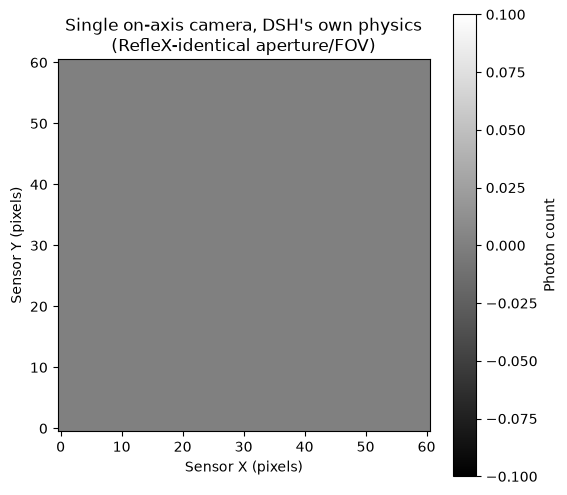

In [7]:
CAMERA_DISTANCE_PC = SOURCE_DISTANCE_PC  # 10,000 pc -- matches disc_comparison.par's IMAGE Z
APERTURE_RADIUS_PC = 1.0e17 / PC_TO_CM   # matches disc_comparison.par's A = 1.0e17 cm
FOV_DEG_SINGLE = 0.08333                  # matches disc_comparison.par's F
IMAGE_SIZE_SINGLE = 61                    # matches disc_comparison.par's N

single_camera = [(0.0, 0.0, CAMERA_DISTANCE_PC)]
single_image = render_pinhole_cameras(
    loc_reflex, dir_reflex, single_camera,
    aperture_radius=APERTURE_RADIUS_PC, fov_deg=FOV_DEG_SINGLE, image_size=IMAGE_SIZE_SINGLE,
)

print(f"{loc_reflex.shape[0]} candidate dust-scattering events")
print(f"{single_image.sum():.0f} landed in the single-camera image, "
      f"{np.count_nonzero(single_image)} nonzero pixels")

plt.figure(figsize=(6, 6))
plt.imshow(np.flipud(single_image), cmap="gray", origin="lower", interpolation="none")
plt.xlabel("Sensor X (pixels)")
plt.ylabel("Sensor Y (pixels)")
plt.title("Single on-axis camera, DSH's own physics\n(RefleX-identical aperture/FOV)")
plt.colorbar(label="Photon count")
plt.show()

## Test 2: tiled camera grid

Matches the `173_MC80_simplified_nh_10_e22/params.par` reference file's technique: many small,
edge-to-edge apertures spread across the field, each contributing to the same combined image.
The aperture here is deliberately larger than the single-camera test above (trading resolution
for tractable coverage/statistics with a modest number of cameras).

camera grid: 27 x 27 = 729 cameras, aperture 1.0 pc, spanning +/-13.0 pc
212 total counts, 180 nonzero pixels


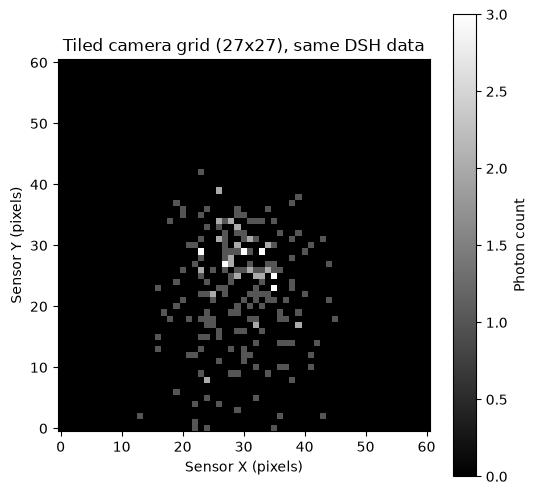

In [8]:
GRID_APERTURE_PC = 1.0
GRID_HALF_EXTENT_PC = 13.0
grid_coords = np.arange(-GRID_HALF_EXTENT_PC, GRID_HALF_EXTENT_PC + GRID_APERTURE_PC, GRID_APERTURE_PC)
print(f"camera grid: {grid_coords.size} x {grid_coords.size} = {grid_coords.size ** 2} cameras, "
      f"aperture {GRID_APERTURE_PC} pc, spanning +/-{GRID_HALF_EXTENT_PC} pc")

grid_cameras = [(x0, y0, CAMERA_DISTANCE_PC) for x0 in grid_coords for y0 in grid_coords]
grid_image = render_pinhole_cameras(
    loc_reflex, dir_reflex, grid_cameras,
    aperture_radius=GRID_APERTURE_PC, fov_deg=FOV_DEG_SINGLE, image_size=IMAGE_SIZE_SINGLE,
)

print(f"{grid_image.sum():.0f} total counts, {np.count_nonzero(grid_image)} nonzero pixels")

plt.figure(figsize=(6, 6))
plt.imshow(np.flipud(grid_image), cmap="gray", origin="lower", interpolation="none")
plt.xlabel("Sensor X (pixels)")
plt.ylabel("Sensor Y (pixels)")
plt.title(f"Tiled camera grid ({grid_coords.size}x{grid_coords.size}), same DSH data")
plt.colorbar(label="Photon count")
plt.show()

## Sanity check: compare against DSH's own true (peel-off) image

Runs the same cloud/source/physics through DSH's actual ideal-observer pipeline (peel-off,
zero aperture) and compares its radial profile to the tiled-camera reconstruction above --
checking whether camera-tiling actually recovers the true halo shape.

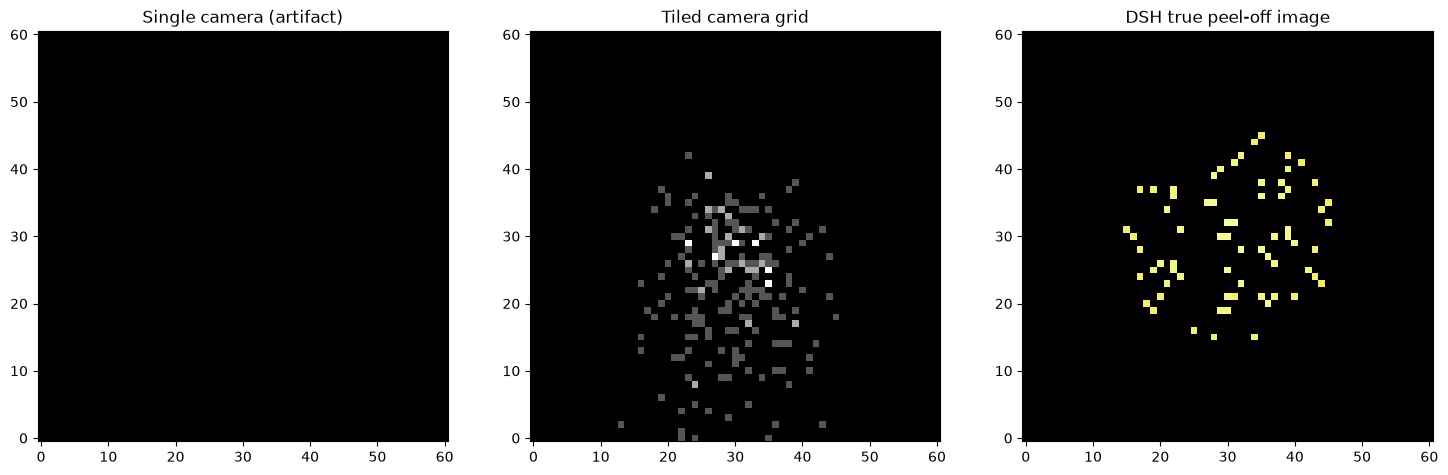

  r (arcsec)   grid-camera frac    DSH true frac
  [  0, 10)             0.0472           0.1000
  [ 10, 20)             0.0896           0.1979
  [ 20, 30)             0.1745           0.1291
  [ 30, 40)             0.0943           0.1125
  [ 40, 50)             0.1321           0.1556
  [ 50, 60)             0.0849           0.1768
  [ 60, 70)             0.0943           0.0590
  [ 70, 80)             0.0613           0.0691
  [ 80, 90)             0.0519           0.0000
  [ 90,100)             0.0330           0.0000
  [100,110)             0.0472           0.0000
  [110,120)             0.0283           0.0000
  [120,130)             0.0094           0.0000
  [130,140)             0.0189           0.0000
  [140,150)             0.0047           0.0000


In [9]:
bin_geometry = build_observer_bin_geometry(
    sky_x_edges_arcsec=np.asarray(cloud.x_edges_arcsec),
    sky_y_edges_arcsec=np.asarray(cloud.y_edges_arcsec),
    energy_edges_kev=centers_to_edges(scattering.energy_kev),
    arrival_time_edges_s=np.array([0.0, 1.0e12]),  # one huge bin -- only the sky image matters here
)

result = run_tabulated_source_to_observer_chunked(
    random.PRNGKey(SEED + 1),
    source,
    launch_geometry,
    cloud,
    physics,
    bin_geometry,
    total_packets=TOTAL_PACKETS,
    chunk_size=BATCH_SIZE,
    max_interactions=MAX_INTERACTIONS,
)
dsh_true_image = np.asarray(result.products.total_fluence).sum(axis=(0, 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(np.flipud(single_image), cmap="gray", origin="lower")
axes[0].set_title("Single camera (artifact)")
axes[1].imshow(np.flipud(grid_image), cmap="gray", origin="lower")
axes[1].set_title("Tiled camera grid")
axes[2].imshow(np.log10(dsh_true_image + 1e-30), cmap="inferno", origin="lower")
axes[2].set_title("DSH true peel-off image")
plt.show()

# radial profile comparison, each normalized to its own total
x_edges = np.asarray(bin_geometry.sky_x_edges_arcsec)
y_edges = np.asarray(bin_geometry.sky_y_edges_arcsec)
x_c = 0.5 * (x_edges[:-1] + x_edges[1:])
y_c = 0.5 * (y_edges[:-1] + y_edges[1:])
yy, xx = np.meshgrid(y_c, x_c, indexing="ij")
r_grid = np.sqrt(xx**2 + yy**2)

bins = np.arange(0, 160, 10)
grid_norm = grid_image / grid_image.sum()
dsh_norm = dsh_true_image / dsh_true_image.sum()
print(f"{'r (arcsec)':>12} {'grid-camera frac':>18} {'DSH true frac':>16}")
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (r_grid >= lo) & (r_grid < hi)
    print(f"  [{lo:3d},{hi:3d}) {grid_norm[mask].sum():18.4f} {dsh_norm[mask].sum():16.4f}")